# Análise das Avaliações de Questões de Pensamento Computacional

Este notebook realiza a análise dos dados coletados por meio de um questionário aplicado a professores de Matemática. O objetivo é comparar questões elaboradas por humanos e questões geradas por ferramentas de IA Generativa, considerando critérios como alinhamento ao Pensamento Computacional, clareza, dificuldade, qualidade pedagógica e interdisciplinaridade.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import files

In [6]:
# Caminho do arquivo CSV
caminho_csv = "/content/respostas_avaliadores.csv"

# Leitura do arquivo
df = pd.read_csv(caminho_csv)

print("Arquivo CSV lido com sucesso!")
print(f"Quantidade de respostas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

df.head()

Arquivo CSV lido com sucesso!
Quantidade de respostas: 3
Quantidade de colunas: 105


,Carimbo de data/hora,Informe qual é a sua área de formação.,Informe qual é o seu tempo de experiência docente.,Informe qual é a sua área de atuação.,Informe se você atua no ensino médio,"Critério 1\nA questão está alinhada às competências do Pensamento Computacional, considerando habilidades como abstração, decomposição, reconhecimento de padrões e elaboração de algoritmos.",Critério 2\nO enunciado da questão é claro e de fácil compreensão.,Critério 3\nO nível de dificuldade da questão é adequado ao Ensino Médio Técnico.,Critério 4\nA questão apresenta boa qualidade pedagógica.,Critério 5\nA questão apresenta potencial interdisciplinar.,...,"Critério 1\nA questão está alinhada às competências do Pensamento Computacional, considerando habilidades como abstração, decomposição, reconhecimento de padrões e elaboração de algoritmos. .17",Critério 2\nO enunciado da questão é claro e de fácil compreensão..17,Critério 3\nO nível de dificuldade da questão é adequado ao Ensino Médio Técnico..17,Critério 4\nA questão apresenta boa qualidade pedagógica..17,Critério 5\nA questão apresenta potencial interdisciplinar..17,"Critério 1\nA questão está alinhada às competências do Pensamento Computacional, considerando habilidades como abstração, decomposição, reconhecimento de padrões e elaboração de algoritmos. .18",Critério 2\nO enunciado da questão é claro e de fácil compreensão..18,Critério 3\nO nível de dificuldade da questão é adequado ao Ensino Médio Técnico..18,Critério 4\nA questão apresenta boa qualidade pedagógica..18,Critério 5\nA questão apresenta potencial interdisciplinar..18
0,2026/07/04 10:22:48 p.m. GMT-3,Matemática,Menos de 5 anos,Coordenação Pedagógica,Sim,4,3,4,3,5,...,5,5,5,5,4,5,4,5,5,5
1,2026/07/04 11:00:47 p.m. GMT-3,Matemática,Menos de 5 anos,Matemática,Não,4,4,5,3,2,...,5,5,4,5,5,5,5,5,5,5
2,2026/07/05 9:54:38 p.m. GMT-3,Matemática,De 5 a 10 anos,Física,Sim,4,4,4,4,4,...,5,4,5,5,5,5,5,5,5,5


In [7]:
print("Número de avaliadores:", len(df))

print("\nInformações das colunas:")
print(df.columns)

print("\nPrimeiras linhas da base:")
display(df.head())

Número de avaliadores: 3

Informações das colunas:
Index(['Carimbo de data/hora', 'Informe qual é a sua área de formação.',
       'Informe qual é o seu tempo de experiência docente.',
       'Informe qual é a sua área de atuação.',
       'Informe se você atua no ensino médio',
       'Critério 1\nA questão está alinhada às competências do Pensamento Computacional, considerando habilidades como abstração, decomposição, reconhecimento de padrões e elaboração de algoritmos.  ',
       'Critério 2\nO enunciado da questão é claro e de fácil compreensão.',
       'Critério 3\nO nível de dificuldade da questão é adequado ao Ensino Médio Técnico.',
       'Critério 4\nA questão apresenta boa qualidade pedagógica.',
       'Critério 5\nA questão apresenta potencial interdisciplinar.',
       ...
       'Critério 1\nA questão está alinhada às competências do Pensamento Computacional, considerando habilidades como abstração, decomposição, reconhecimento de padrões e elaboração de algoritmos.  .

,Carimbo de data/hora,Informe qual é a sua área de formação.,Informe qual é o seu tempo de experiência docente.,Informe qual é a sua área de atuação.,Informe se você atua no ensino médio,"Critério 1\nA questão está alinhada às competências do Pensamento Computacional, considerando habilidades como abstração, decomposição, reconhecimento de padrões e elaboração de algoritmos.",Critério 2\nO enunciado da questão é claro e de fácil compreensão.,Critério 3\nO nível de dificuldade da questão é adequado ao Ensino Médio Técnico.,Critério 4\nA questão apresenta boa qualidade pedagógica.,Critério 5\nA questão apresenta potencial interdisciplinar.,...,"Critério 1\nA questão está alinhada às competências do Pensamento Computacional, considerando habilidades como abstração, decomposição, reconhecimento de padrões e elaboração de algoritmos. .17",Critério 2\nO enunciado da questão é claro e de fácil compreensão..17,Critério 3\nO nível de dificuldade da questão é adequado ao Ensino Médio Técnico..17,Critério 4\nA questão apresenta boa qualidade pedagógica..17,Critério 5\nA questão apresenta potencial interdisciplinar..17,"Critério 1\nA questão está alinhada às competências do Pensamento Computacional, considerando habilidades como abstração, decomposição, reconhecimento de padrões e elaboração de algoritmos. .18",Critério 2\nO enunciado da questão é claro e de fácil compreensão..18,Critério 3\nO nível de dificuldade da questão é adequado ao Ensino Médio Técnico..18,Critério 4\nA questão apresenta boa qualidade pedagógica..18,Critério 5\nA questão apresenta potencial interdisciplinar..18
0,2026/07/04 10:22:48 p.m. GMT-3,Matemática,Menos de 5 anos,Coordenação Pedagógica,Sim,4,3,4,3,5,...,5,5,5,5,4,5,4,5,5,5
1,2026/07/04 11:00:47 p.m. GMT-3,Matemática,Menos de 5 anos,Matemática,Não,4,4,5,3,2,...,5,5,4,5,5,5,5,5,5,5
2,2026/07/05 9:54:38 p.m. GMT-3,Matemática,De 5 a 10 anos,Física,Sim,4,4,4,4,4,...,5,4,5,5,5,5,5,5,5,5


In [8]:
origens_questoes = {
    1: "Tese",
    2: "Tese",
    3: "Tese",
    4: "ChatGPT",
    5: "Gemini",
    6: "Tese",
    7: "Gemini",
    8: "OBI",
    9: "ChatGPT",
    10: "OBI",
    11: "Gemini",
    12: "ChatGPT",
    13: "OBI",
    14: "OBI",
    15: "Gemini",
    16: "ChatGPT",
    17: "OBI",
    18: "Gemini",
    19: "OBI",
    20: "ChatGPT"
}

criterios = [
    "Pensamento Computacional",
    "Clareza",
    "Dificuldade",
    "Qualidade Pedagógica",
    "Interdisciplinaridade"
]

In [9]:
colunas_perfil = df.columns[:5]
colunas_avaliacao = df.columns[5:]

dados = []

for indice_coluna, coluna in enumerate(colunas_avaliacao):
    numero_questao = (indice_coluna // 5) + 1
    criterio = criterios[indice_coluna % 5]
    origem = origens_questoes[numero_questao]
    grupo = "Humana" if origem in ["Tese", "OBI"] else "IA"

    for avaliador, nota in enumerate(df[coluna], start=1):
        dados.append({
            "Avaliador": avaliador,
            "Questao": numero_questao,
            "Origem": origem,
            "Grupo": grupo,
            "Criterio": criterio,
            "Nota": nota
        })

dados_longos = pd.DataFrame(dados)

dados_longos.head()

,Avaliador,Questao,Origem,Grupo,Criterio,Nota
0,1,1,Tese,Humana,Pensamento Computacional,4
1,2,1,Tese,Humana,Pensamento Computacional,4
2,3,1,Tese,Humana,Pensamento Computacional,4
3,1,1,Tese,Humana,Clareza,3
4,2,1,Tese,Humana,Clareza,4


In [10]:
perfil_avaliadores = df[colunas_perfil]

perfil_avaliadores

,Carimbo de data/hora,Informe qual é a sua área de formação.,Informe qual é o seu tempo de experiência docente.,Informe qual é a sua área de atuação.,Informe se você atua no ensino médio
0,2026/07/04 10:22:48 p.m. GMT-3,Matemática,Menos de 5 anos,Coordenação Pedagógica,Sim
1,2026/07/04 11:00:47 p.m. GMT-3,Matemática,Menos de 5 anos,Matemática,Não
2,2026/07/05 9:54:38 p.m. GMT-3,Matemática,De 5 a 10 anos,Física,Sim


In [11]:
# Resumo da caracterização dos avaliadores

print("Quantidade de avaliadores:", len(df))

print("\nÁrea de formação:")
print(df.iloc[:, 1].value_counts())

print("\nTempo de experiência docente:")
print(df.iloc[:, 2].value_counts())

print("\nÁrea de atuação:")
print(df.iloc[:, 3].value_counts())

print("\nAtua no Ensino Médio:")
print(df.iloc[:, 4].value_counts())

Quantidade de avaliadores: 3

Área de formação:
Informe qual é a sua área de formação.
Matemática    3
Name: count, dtype: int64

Tempo de experiência docente:
Informe qual é o seu tempo de experiência docente.
Menos de 5 anos    2
De 5 a 10 anos     1
Name: count, dtype: int64

Área de atuação:
Informe qual é a sua área de atuação.
Coordenação Pedagógica     1
Matemática                 1
Física                     1
Name: count, dtype: int64

Atua no Ensino Médio:
Informe se você atua no ensino médio
Sim    2
Não    1
Name: count, dtype: int64


In [12]:
media_por_origem = dados_longos.groupby("Origem")["Nota"].agg(
    Media="mean",
    Mediana="median",
    Desvio_Padrao="std"
).reset_index()

media_por_origem

,Origem,Media,Mediana,Desvio_Padrao
0,ChatGPT,4.493333,5.0,0.554425
1,Gemini,4.373333,5.0,0.784535
2,OBI,4.344444,4.0,0.781257
3,Tese,4.200000,4.0,0.898209


In [13]:
tabela_distribuicao = pd.DataFrame({

    "Origem": ["Tese","OBI","ChatGPT","Gemini"],

    "Quantidade": [4,6,5,5],

    "Grupo": ["Humana","Humana","IA","IA"]

})

tabela_distribuicao

,Origem,Quantidade,Grupo
0,Tese,4,Humana
1,OBI,6,Humana
2,ChatGPT,5,IA
3,Gemini,5,IA


In [14]:
tabela_resumo = media_por_origem.copy()

tabela_resumo["Media"] = tabela_resumo["Media"].round(2)

tabela_resumo["Mediana"] = tabela_resumo["Mediana"].round(2)

tabela_resumo["Desvio_Padrao"] = tabela_resumo["Desvio_Padrao"].round(2)

tabela_resumo

,Origem,Media,Mediana,Desvio_Padrao
0,ChatGPT,4.49,5.0,0.55
1,Gemini,4.37,5.0,0.78
2,OBI,4.34,4.0,0.78
3,Tese,4.20,4.0,0.90


In [15]:
media_criterio_origem = dados_longos.groupby(
    ["Origem", "Criterio"]
)["Nota"].agg(
    Media="mean",
    Mediana="median",
    Desvio_Padrao="std"
).reset_index()

media_criterio_origem

,Origem,Criterio,Media,Mediana,Desvio_Padrao
0,ChatGPT,Clareza,4.533333,5.0,0.516398
1,ChatGPT,Dificuldade,4.466667,4.0,0.516398
2,ChatGPT,Interdisciplinaridade,4.400000,4.0,0.507093
3,ChatGPT,Pensamento Computacional,4.466667,5.0,0.743223
4,ChatGPT,Qualidade Pedagógica,4.600000,5.0,0.507093
5,Gemini,Clareza,4.066667,4.0,1.162919
6,Gemini,Dificuldade,4.200000,4.0,0.676123
7,Gemini,Interdisciplinaridade,4.800000,5.0,0.414039
8,Gemini,Pensamento Computacional,4.733333,5.0,0.457738
9,Gemini,Qualidade Pedagógica,4.066667,4.0,0.703732


In [16]:
media_por_grupo = dados_longos.groupby("Grupo")["Nota"].agg(
    Media="mean",
    Mediana="median",
    Desvio_Padrao="std"
).reset_index()

media_por_grupo

,Grupo,Media,Mediana,Desvio_Padrao
0,Humana,4.286667,4.0,0.830110
1,IA,4.433333,5.0,0.679683


In [17]:
media_criterio_grupo = dados_longos.groupby(
    ["Grupo", "Criterio"]
)["Nota"].agg(
    Media="mean",
    Mediana="median",
    Desvio_Padrao="std"
).reset_index()

media_criterio_grupo

,Grupo,Criterio,Media,Mediana,Desvio_Padrao
0,Humana,Clareza,4.466667,4.5,0.571346
1,Humana,Dificuldade,4.500000,4.5,0.508548
2,Humana,Interdisciplinaridade,3.833333,4.0,1.205829
3,Humana,Pensamento Computacional,4.233333,4.0,0.897634
4,Humana,Qualidade Pedagógica,4.400000,4.0,0.621455
5,IA,Clareza,4.300000,4.5,0.915386
6,IA,Dificuldade,4.333333,4.0,0.606478
7,IA,Interdisciplinaridade,4.600000,5.0,0.498273
8,IA,Pensamento Computacional,4.600000,5.0,0.621455
9,IA,Qualidade Pedagógica,4.333333,4.0,0.660895


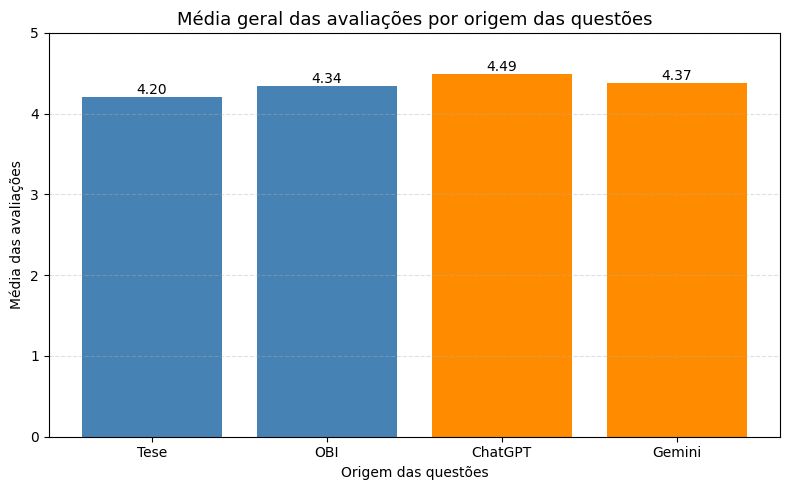

In [18]:
# Ordena as origens na sequência desejada
ordem_origem = ["Tese", "OBI", "ChatGPT", "Gemini"]

media_plot = media_por_origem.set_index("Origem").loc[ordem_origem].reset_index()

# Azul para questões humanas e laranja para IA
cores = ["steelblue", "steelblue", "darkorange", "darkorange"]

plt.figure(figsize=(8,5))

barras = plt.bar(
    media_plot["Origem"],
    media_plot["Media"],
    color=cores
)

plt.ylim(0,5)

plt.title("Média geral das avaliações por origem das questões", fontsize=13)

plt.xlabel("Origem das questões")

plt.ylabel("Média das avaliações")

plt.grid(axis="y", linestyle="--", alpha=0.4)

# Exibe o valor acima das barras
for barra in barras:
    y = barra.get_height()
    plt.text(
        barra.get_x()+barra.get_width()/2,
        y+0.04,
        f"{y:.2f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig("grafico_media_por_origem.png", dpi=300)

plt.show()

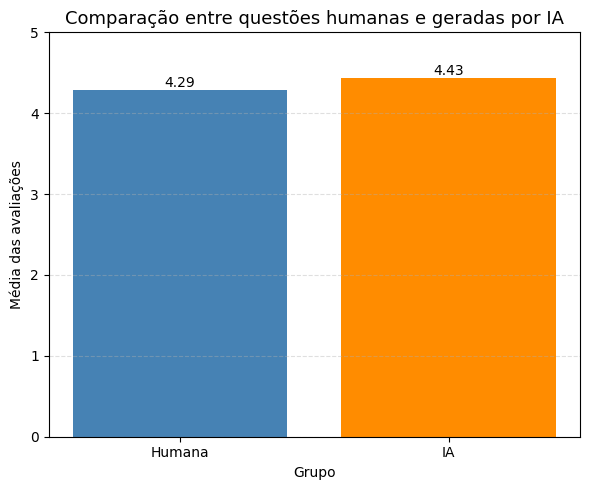

In [19]:
cores = ["steelblue","darkorange"]

plt.figure(figsize=(6,5))

barras = plt.bar(
    media_por_grupo["Grupo"],
    media_por_grupo["Media"],
    color=cores
)

plt.ylim(0,5)

plt.title("Comparação entre questões humanas e geradas por IA", fontsize=13)

plt.xlabel("Grupo")

plt.ylabel("Média das avaliações")

plt.grid(axis="y", linestyle="--", alpha=0.4)

for barra in barras:

    y = barra.get_height()

    plt.text(
        barra.get_x()+barra.get_width()/2,
        y+0.04,
        f"{y:.2f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig("grafico_humanas_vs_ia.png", dpi=300)

plt.show()

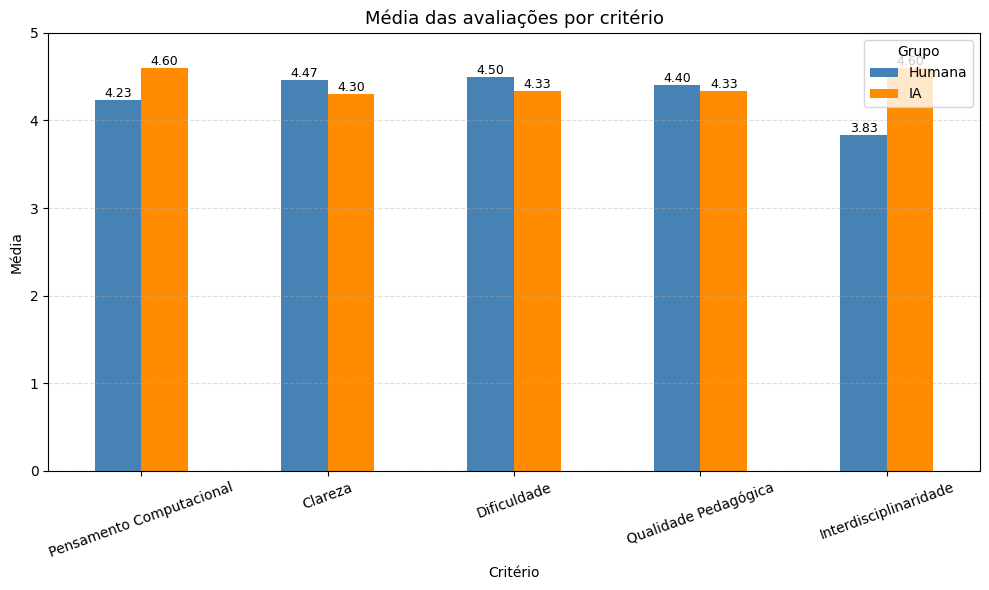

In [20]:
ordem = [
    "Pensamento Computacional",
    "Clareza",
    "Dificuldade",
    "Qualidade Pedagógica",
    "Interdisciplinaridade"
]

pivot = media_criterio_grupo.pivot(
    index="Criterio",
    columns="Grupo",
    values="Media"
).loc[ordem]

ax = pivot.plot(
    kind="bar",
    figsize=(10,6),
    color=["steelblue","darkorange"]
)

plt.ylim(0,5)

plt.title("Média das avaliações por critério", fontsize=13)

plt.xlabel("Critério")

plt.ylabel("Média")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9)

plt.tight_layout()

plt.savefig("grafico_criterios_por_grupo.png", dpi=300)

plt.show()

In [21]:
media_por_questao = dados_longos.groupby(
    ["Questao", "Origem", "Grupo"]
)["Nota"].agg(
    Media="mean",
    Mediana="median",
    Desvio_Padrao="std"
).reset_index()

media_por_questao

,Questao,Origem,Grupo,Media,Mediana,Desvio_Padrao
0,1,Tese,Humana,3.800000,4.0,0.774597
1,2,Tese,Humana,4.200000,4.0,0.414039
2,3,Tese,Humana,4.733333,5.0,0.593617
3,4,ChatGPT,IA,4.600000,5.0,0.507093
4,5,Gemini,IA,4.066667,4.0,0.798809
5,6,Tese,Humana,4.066667,5.0,1.334523
6,7,Gemini,IA,4.400000,5.0,0.985611
7,8,OBI,Humana,4.133333,4.0,0.915475
8,9,ChatGPT,IA,4.200000,4.0,0.414039
9,10,OBI,Humana,4.333333,5.0,1.046536


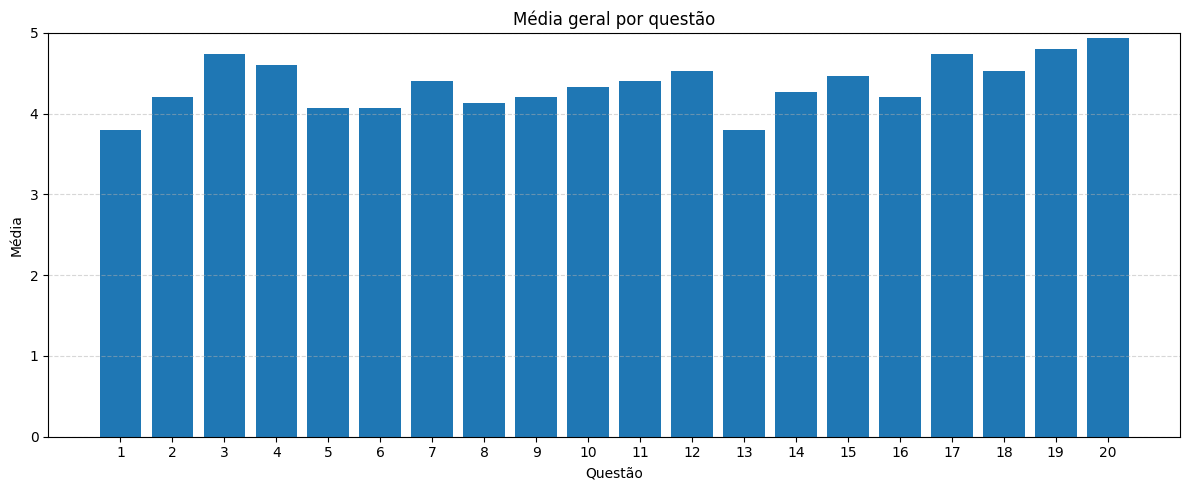

In [22]:
plt.figure(figsize=(12, 5))
plt.bar(media_por_questao["Questao"].astype(str), media_por_questao["Media"])
plt.ylim(0, 5)
plt.title("Média geral por questão")
plt.xlabel("Questão")
plt.ylabel("Média")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("grafico_media_por_questao.png", dpi=300)
plt.show()

In [24]:
media_por_origem.to_csv("media_por_origem.csv", index=False)
media_por_grupo.to_csv("media_por_grupo.csv", index=False)
media_criterio_origem.to_csv("media_criterio_origem.csv", index=False)
media_criterio_grupo.to_csv("media_criterio_grupo.csv", index=False)
media_por_questao.to_csv("media_por_questao.csv", index=False)
dados_longos.to_csv("dados_organizados.csv", index=False)

print("Tabelas salvas com sucesso.")

Tabelas salvas com sucesso.


In [26]:
arquivos_saida = [
    "media_por_origem.csv",
    "media_por_grupo.csv",
    "media_criterio_origem.csv",
    "media_criterio_grupo.csv",
    "media_por_questao.csv",
    "dados_organizados.csv",
    "grafico_media_por_origem.png",
    "grafico_humanas_vs_ia.png",
    "grafico_criterios_por_grupo.png",
    "grafico_media_por_questao.png"
]

for arquivo in arquivos_saida:
    files.download(arquivo)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>